<a href="https://colab.research.google.com/github/noahcoulson/mis433/blob/main/Copy_of_assignment_IMDB_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [2]:
import pandas as pd
import numpy as np

In [5]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [4]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [8]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb['Released_Year'].value_counts()

,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [6]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
imdb['Released_Year'].unique()

array(['1994', '1972', '2008', '1974', '1957', '2003', '1993', '2010',
       '1999', '2001', '1966', '2002', '1990', '1980', '1975', '2020',
       '2019', '2014', '1998', '1997', '1995', '1991', '1977', '1962',
       '1954', '1946', '2011', '2006', '2000', '1988', '1985', '1968',
       '1960', '1942', '1936', '1931', '2018', '2017', '2016', '2012',
       '2009', '2007', '1984', '1981', '1979', '1971', '1963', '1964',
       '1950', '1940', '2013', '2005', '2004', '1992', '1987', '1986',
       '1983', '1976', '1973', '1965', '1959', '1958', '1952', '1948',
       '1944', '1941', '1927', '1921', '2015', '1996', '1989', '1978',
       '1961', '1955', '1953', '1925', '1924', '1982', '1967', '1951',
       '1949', '1939', '1937', '1934', '1928', '1926', '1920', '1970',
       '1969', '1956', '1947', '1945', '1930', '1938', '1935', '1933',
       '1932', '1922', '1943', 'PG'], dtype=object)

In [9]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value
imdb.loc[imdb['Released_Year'] == 'PG'].index
imdb.loc[966, 'Released_Year'] = 1995
imdb.loc[966, 'Certificate'] = 'PG'
imdb.loc[966]

,966
Poster_Link,https://m.media-amazon.com/images/M/MV5BNjEzYj...
Series_Title,Apollo 13
Released_Year,1995
Certificate,PG
Runtime,140 min
Genre,"Adventure, Drama, History"
IMDB_Rating,7.6
Overview,NASA must devise a strategy to return Apollo 1...
Meta_score,77.0
Director,Ron Howard


In [11]:
# Change the data type of "Released_Year" to int
imdb['Released_Year'] = imdb['Released_Year'].astype(int)

In [16]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
df1 = imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]
df1[['Series_Title', 'Certificate', 'Gross']].sort_values('Gross', ascending = False)

,Series_Title,Certificate,Gross
33,Joker,A,335451311.0
8,Inception,UA,292576195.0
21,Interstellar,UA,188020017.0
19,Gisaengchung,A,53367844.0
35,The Intouchables,UA,13182281.0
34,Whiplash,A,13092000.0
18,Hamilton,PG-13,NaN
20,Soorarai Pottru,U,NaN


In [ ]:
# Does the sorting result looks right to you? What's the problem?
# The sorting is incorrect because the Gross variable datatype is not a number type

In [12]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe
imdb['Gross'] = imdb['Gross'].str.replace(',', '')
imdb['Gross'] = imdb['Gross'].astype(float)

In [17]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
df1[['Series_Title', 'Certificate', 'Gross']].sort_values('Gross', ascending = False)

,Series_Title,Certificate,Gross
33,Joker,A,335451311.0
8,Inception,UA,292576195.0
21,Interstellar,UA,188020017.0
19,Gisaengchung,A,53367844.0
35,The Intouchables,UA,13182281.0
34,Whiplash,A,13092000.0
18,Hamilton,PG-13,NaN
20,Soorarai Pottru,U,NaN


In [13]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe
imdb['Runtime_min'] = imdb['Runtime'].str.replace(' min', '').astype(int)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,142
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,202
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,96


In [14]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
imdb['Age_Year'] = 2026 - imdb['Released_Year']
imdb[['Series_Title', 'Released_Year', 'Age_Year']]

,Series_Title,Released_Year,Age_Year
0,The Shawshank Redemption,1994,32
1,The Godfather,1972,54
2,The Dark Knight,2008,18
3,The Godfather: Part II,1974,52
4,12 Angry Men,1957,69
...,...,...,...
995,Breakfast at Tiffany's,1961,65
996,Giant,1956,70
997,From Here to Eternity,1953,73
998,Lifeboat,1944,82


In [15]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
imdb['Decade'] = imdb['Released_Year'] // 10 * 10
imdb[['Series_Title', 'Released_Year', 'Decade']]

,Series_Title,Released_Year,Decade
0,The Shawshank Redemption,1994,1990
1,The Godfather,1972,1970
2,The Dark Knight,2008,2000
3,The Godfather: Part II,1974,1970
4,12 Angry Men,1957,1950
...,...,...,...
995,Breakfast at Tiffany's,1961,1960
996,Giant,1956,1950
997,From Here to Eternity,1953,1950
998,Lifeboat,1944,1940


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

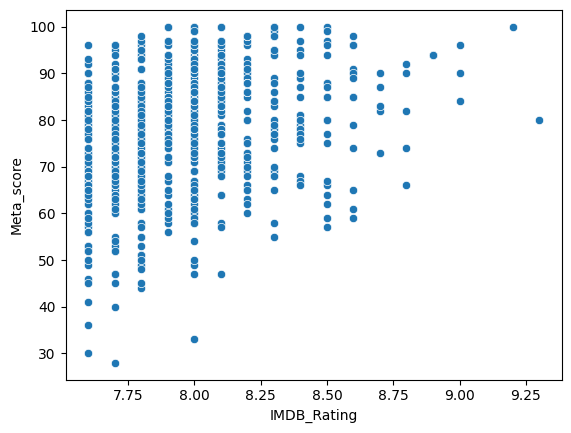

In [25]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.
scatterplot1 = sns.scatterplot(data=imdb, x='IMDB_Rating', y='Meta_score')
plt.show()
# Movies with higher meta scores are more likely to have lower IMDB Ratings.

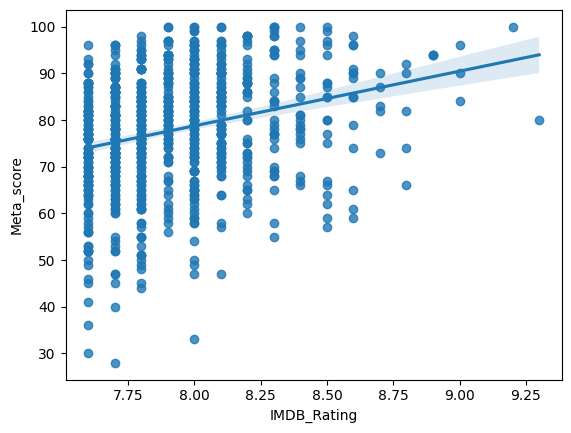

In [30]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.
scatterplot2 = sns.regplot(data=imdb, x = 'IMDB_Rating', y = 'Meta_score', order = 1)

In [ ]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.
# One data point that surprises me is the movie with a IMDB_Rating as high as 9.25 while  its meta score is still relatively high for its rating

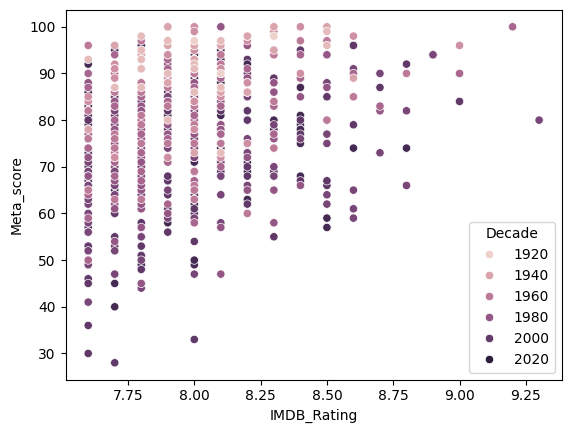

In [16]:
# In the scatterplot, use color to distinguish movies from different decades.
scatterplot2 = sns.scatterplot(data=imdb, x='IMDB_Rating', y='Meta_score', hue = 'Decade')
plt.show()

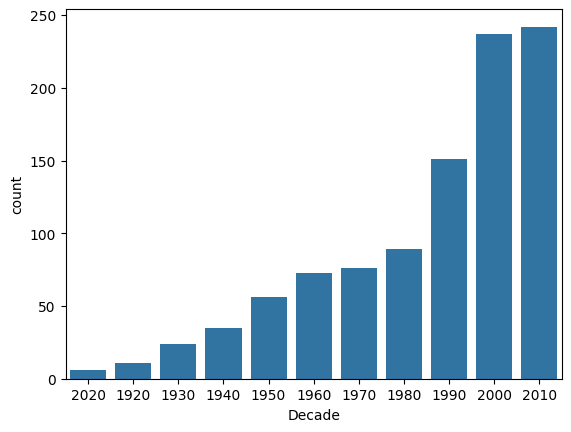

In [17]:
# Create a chart that shows how many movies fall in each decade.
order = imdb['Decade'].value_counts(ascending=True).index
sns.countplot(data=imdb, x='Decade',order=order)
plt.show()

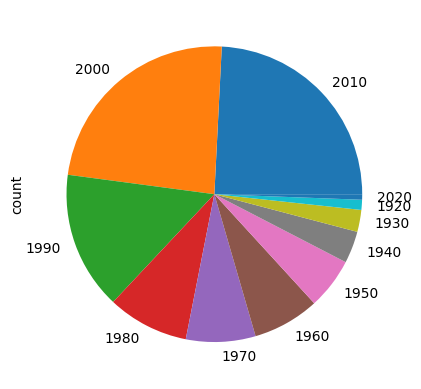

In [18]:
# Create a chart that shows the percentage of movies in each decade.
imdb['Decade'].value_counts().plot(kind='pie')
plt.show()

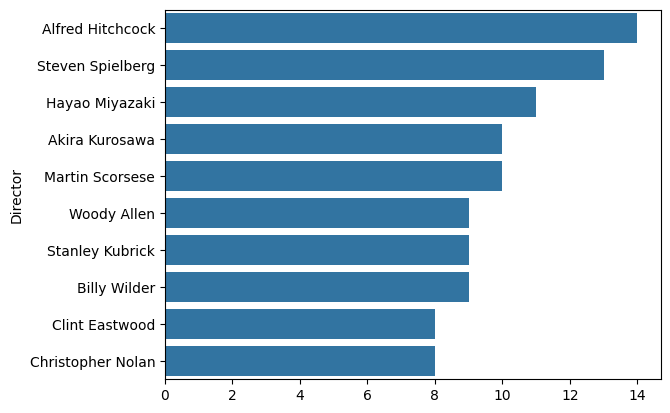

In [20]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.

top_directors = imdb['Director'].value_counts().head(10)
sns.barplot(y=top_directors.index, x=top_directors.values)
plt.show()

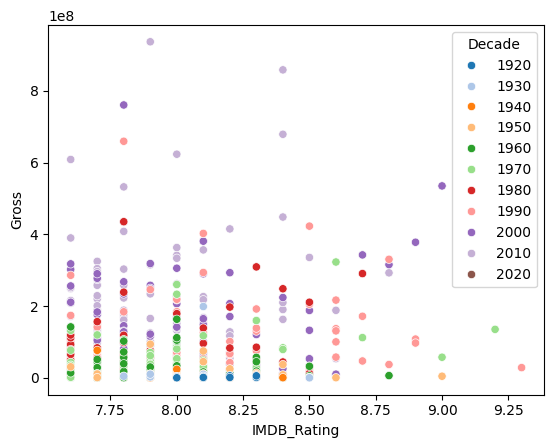

In [22]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.
# To make color differences easier to see, you can try different palettes.
scatterplot3 = sns.scatterplot(data=imdb, x='IMDB_Rating', y='Gross', hue='Decade', palette='tab20')
plt.show()
#There isn't necessarily a relationship between IMDB_Rating and Gross Revenue.
#But it looks like more movies in the 2000 decades are more likely to have higher Gross Revenue

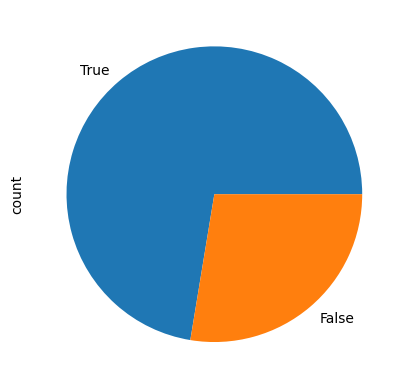

In [26]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.
imdb['Drama'] = imdb['Genre'].str.contains('Drama')
imdb[['Drama', 'Series_Title','Genre']]
imdb['Drama'].value_counts().plot(kind= 'pie')
plt.show()

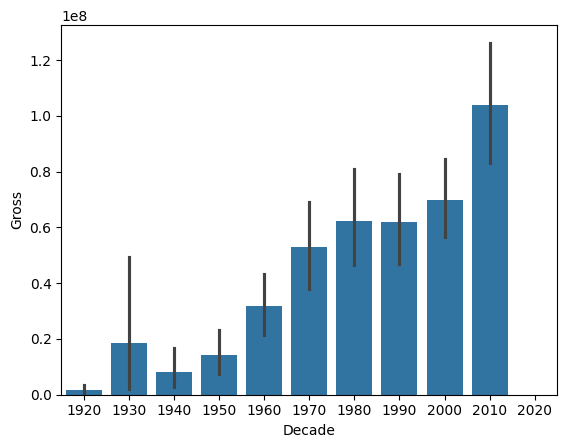

In [28]:
# Create a plot comparing gross revenue across decades.
bargraph = sns.barplot(data=imdb, y = 'Gross', x = 'Decade')
plt.show()

<Axes: xlabel='Gross', ylabel='Count'>

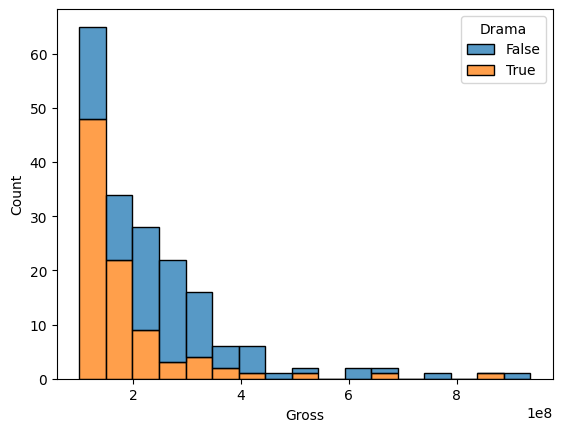

In [30]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.

hundred_million_movies = imdb[imdb['Gross'] > 100_000_000]
sns.histplot(data=hundred_million_movies, x='Gross', hue='Drama', multiple='stack')

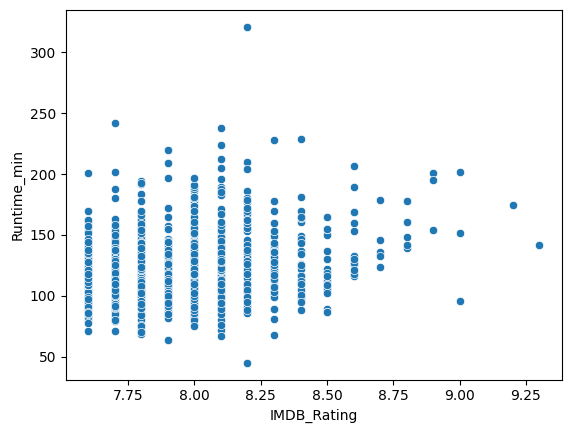

In [33]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: Make a scatterplot comparing IMDB_Rating and Runtime
scatterplot4 = sns.scatterplot(data=imdb, x='IMDB_Rating', y='Runtime_min')
plt.show()


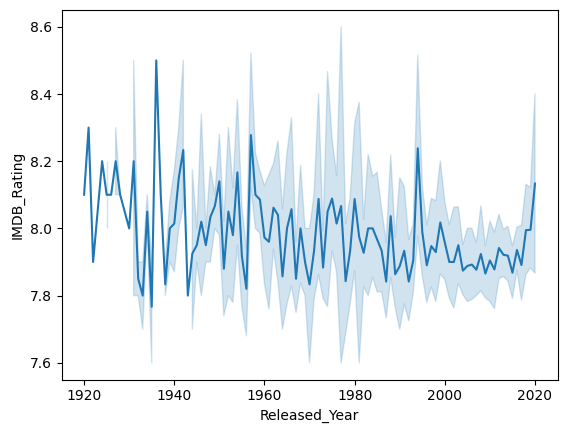

In [35]:
# Question 2: Create a line chart that compares released year and IMDB_Rating
linechart = sns.lineplot(data=imdb, x='Released_Year', y='IMDB_Rating')
plt.show()

